# S6E8 — Audit EDA

Notebook này kiểm tra dữ liệu, drift train/test và signal ban đầu trước khi thử thêm model hoặc feature engineering.

**Nguyên tắc:** EDA dùng train để nhìn target; test chỉ dùng để so sánh distribution/missingness.

In [4]:
from pathlib import Path
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score

ROOT = Path.cwd()
if not (ROOT / 'data').exists():
    ROOT = ROOT.parent
os.chdir(ROOT)

DATA_DIR = ROOT / 'data'
EDA_DIR = ROOT / 'artifacts' / 'eda'
EDA_DIR.mkdir(parents=True, exist_ok=True)

TARGET = 'addicted_label'
ID_COL = 'id'
CAT_COLS = ['gender', 'stress_level', 'academic_work_impact']
sns.set_theme(style='whitegrid', context='notebook')

In [5]:
train = pd.read_csv(DATA_DIR / 'train.csv')
test = pd.read_csv(DATA_DIR / 'test.csv')
sample_submission = pd.read_csv(DATA_DIR / 'sample_submission.csv')

assert TARGET in train.columns
assert TARGET not in test.columns
assert train[ID_COL].is_unique and test[ID_COL].is_unique
assert test[ID_COL].equals(sample_submission[ID_COL])

features = [c for c in test.columns if c != ID_COL]
numeric_cols = [c for c in features if c not in CAT_COLS]
print(f'train: {train.shape[0]:,} rows x {train.shape[1]} columns | test: {test.shape[0]:,} rows x {test.shape[1]} columns')
print(f'positive rate: {train[TARGET].mean():.4%}')
display(train.head())

train: 691,369 rows x 14 columns | test: 296,302 rows x 13 columns
positive rate: 70.9424%


,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


## 1. Schema, cardinality và missingness

,dtype_train,dtype_test,n_unique_train,missing_train_pct,missing_test_pct,missing_delta_pp
social_media_hours,float64,float64,721,19.38,16.00,-3.38
app_opens_per_day,float64,float64,166,11.67,8.68,-3.00
daily_screen_time_hours,float64,float64,1389,13.86,11.07,-2.80
academic_work_impact,object,object,2,6.40,8.68,2.28
work_study_hours,float64,float64,600,7.45,9.37,1.92
notifications_per_day,float64,float64,231,9.78,11.55,1.77
gaming_hours,float64,float64,401,18.34,20.05,1.71
age,float64,float64,18,4.18,5.78,1.60
stress_level,object,object,3,7.98,6.62,-1.35
sleep_hours,float64,float64,451,6.43,7.58,1.14


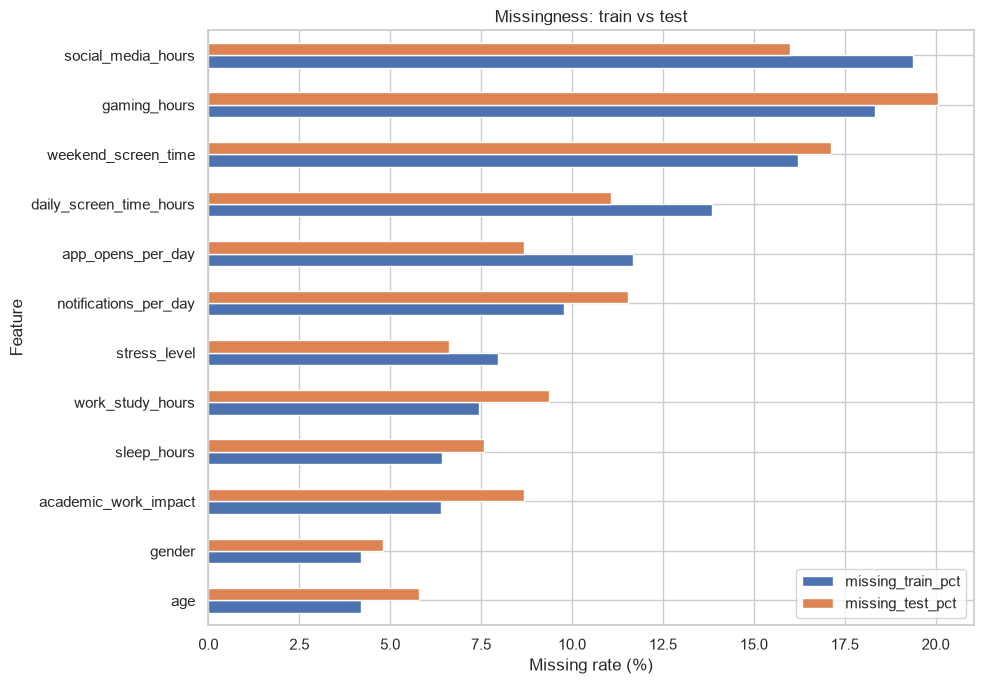

In [11]:
schema = pd.DataFrame({
    'dtype_train': train[features].dtypes.astype(str),
    'dtype_test': test[features].dtypes.astype(str),
    'n_unique_train': train[features].nunique(dropna=True),
    'missing_train_pct': train[features].isna().mean().mul(100),
    'missing_test_pct': test[features].isna().mean().mul(100),
})
schema['missing_delta_pp'] = schema['missing_test_pct'] - schema['missing_train_pct']
schema = schema.sort_values('missing_delta_pp', key=lambda s: s.abs(), ascending=False)
display(schema.round(2))
schema.to_csv(EDA_DIR / 'schema_and_missingness.csv')

ax = schema[['missing_train_pct', 'missing_test_pct']].sort_values('missing_train_pct').plot.barh(figsize=(10, 7))
ax.set(title='Missingness: train vs test', xlabel='Missing rate (%)', ylabel='Feature')
plt.tight_layout()
plt.savefig(EDA_DIR / 'missingness_train_test.png', dpi=160)
plt.show()

## 2. Train/test distribution drift

KS statistic gần 0 nghĩa là distribution numeric giữa train/test khá tương đồng. Đây không thay thế validation, nhưng giúp phát hiện feature có rủi ro drift.

,feature,ks_statistic,p_value
6,notifications_per_day,0.00268,0.14003
5,sleep_hours,0.00218,0.31921
3,gaming_hours,0.00209,0.45975
7,app_opens_per_day,0.00208,0.38943
1,daily_screen_time_hours,0.00173,0.64674
8,weekend_screen_time,0.00167,0.72023
2,social_media_hours,0.00160,0.77026
0,age,0.00145,0.80411
4,work_study_hours,0.00092,0.99735


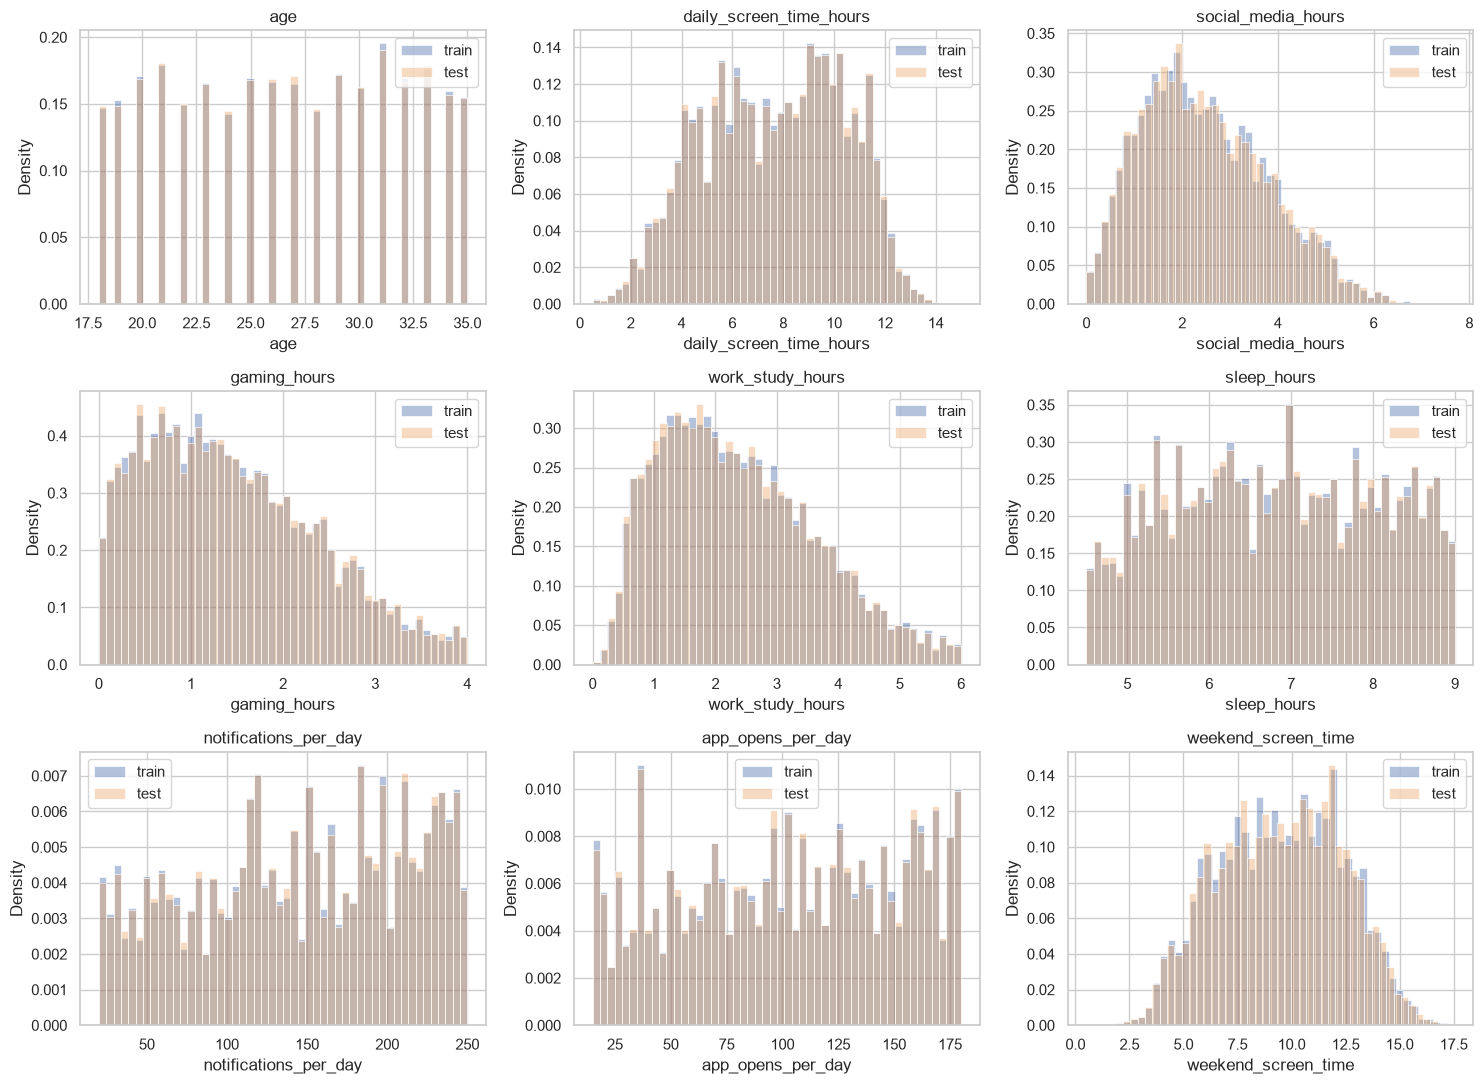

In [12]:
ks_rows = []
for col in numeric_cols:
    statistic, pvalue = ks_2samp(train[col].dropna(), test[col].dropna())
    ks_rows.append({'feature': col, 'ks_statistic': statistic, 'p_value': pvalue})
ks_table = pd.DataFrame(ks_rows).sort_values('ks_statistic', ascending=False)
display(ks_table.round(5))
ks_table.to_csv(EDA_DIR / 'numeric_ks_drift.csv', index=False)

fig, axes = plt.subplots(3, 3, figsize=(15, 11))
for ax, col in zip(axes.flat, numeric_cols):
    sns.histplot(train[col].sample(min(100_000, len(train)), random_state=42), stat='density', bins=50, color="#2a509d", alpha=.35, ax=ax, label='train')
    sns.histplot(test[col].sample(min(100_000, len(test)), random_state=42), stat='density', bins=50, color="#e79a51", alpha=.35, ax=ax, label='test')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.savefig(EDA_DIR / 'numeric_train_test_distributions.png', dpi=160)
plt.show()

## 3. Univariate signal và categorical target rates

AUC đơn biến là benchmark nhanh. Nó không thể hiện interaction giữa features, nhưng chỉ ra biến nào xứng đáng được ưu tiên trong EDA/model interpretation.

In [5]:
univariate_rows = []
for col in numeric_cols:
    prediction = train[col].fillna(train[col].median())
    auc = roc_auc_score(train[TARGET], prediction)
    univariate_rows.append({'feature': col, 'auc': auc, 'absolute_signal_auc': max(auc, 1 - auc)})
univariate_auc = pd.DataFrame(univariate_rows).sort_values('absolute_signal_auc', ascending=False)
display(univariate_auc.round(4))
univariate_auc.to_csv(EDA_DIR / 'univariate_auc.csv', index=False)

for col in CAT_COLS:
    rates = train.groupby(col, dropna=False)[TARGET].agg(['count', 'mean']).sort_values('mean', ascending=False)
    print(f'\n{col}')
    display(rates.style.format({'mean': '{:.2%}', 'count': '{:,.0f}'}))

,feature,auc,absolute_signal_auc
1,daily_screen_time_hours,0.8654,0.8654
8,weekend_screen_time,0.8502,0.8502
2,social_media_hours,0.8178,0.8178
4,work_study_hours,0.6486,0.6486
3,gaming_hours,0.6088,0.6088
7,app_opens_per_day,0.5377,0.5377
5,sleep_hours,0.5253,0.5253
6,notifications_per_day,0.4922,0.5078
0,age,0.5021,0.5021



gender


,count,mean
gender,,
Male,"223,662",72.32%
nan,"29,034",70.88%
Female,"221,595",70.38%
Other,"217,078",70.10%



stress_level


,count,mean
stress_level,,
High,"220,873",71.14%
Low,"207,783",71.12%
nan,"55,148",70.90%
Medium,"207,565",70.57%



academic_work_impact


,count,mean
academic_work_impact,,
No,"316,579",71.10%
nan,"44,224",70.95%
Yes,"330,566",70.79%


## 4. Target-rate curves và 2D surfaces

Dùng bins theo quantile để nhìn nonlinear relationship. Đây là EDA, không biến các bins này thành feature mặc định.

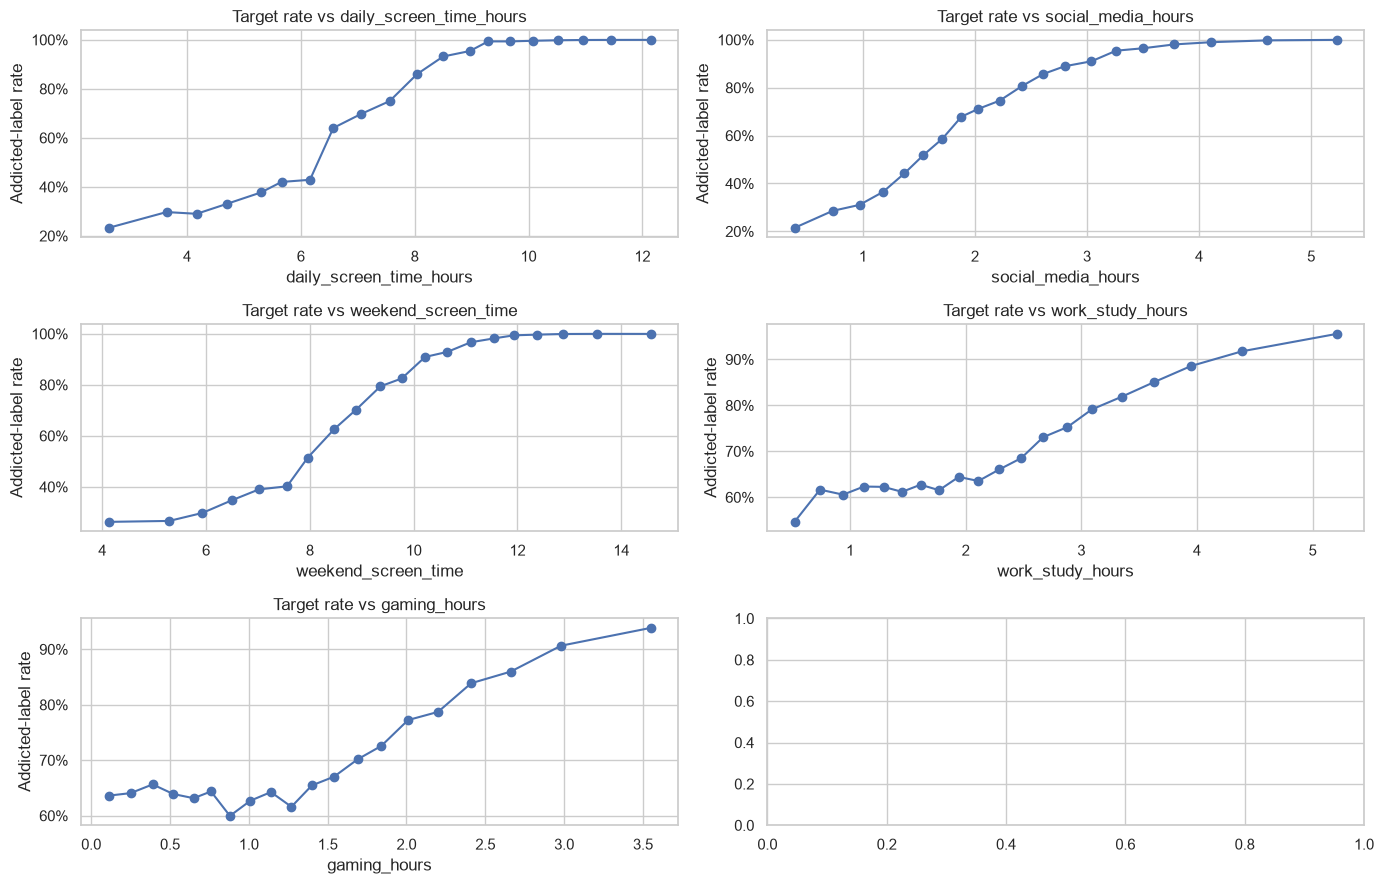

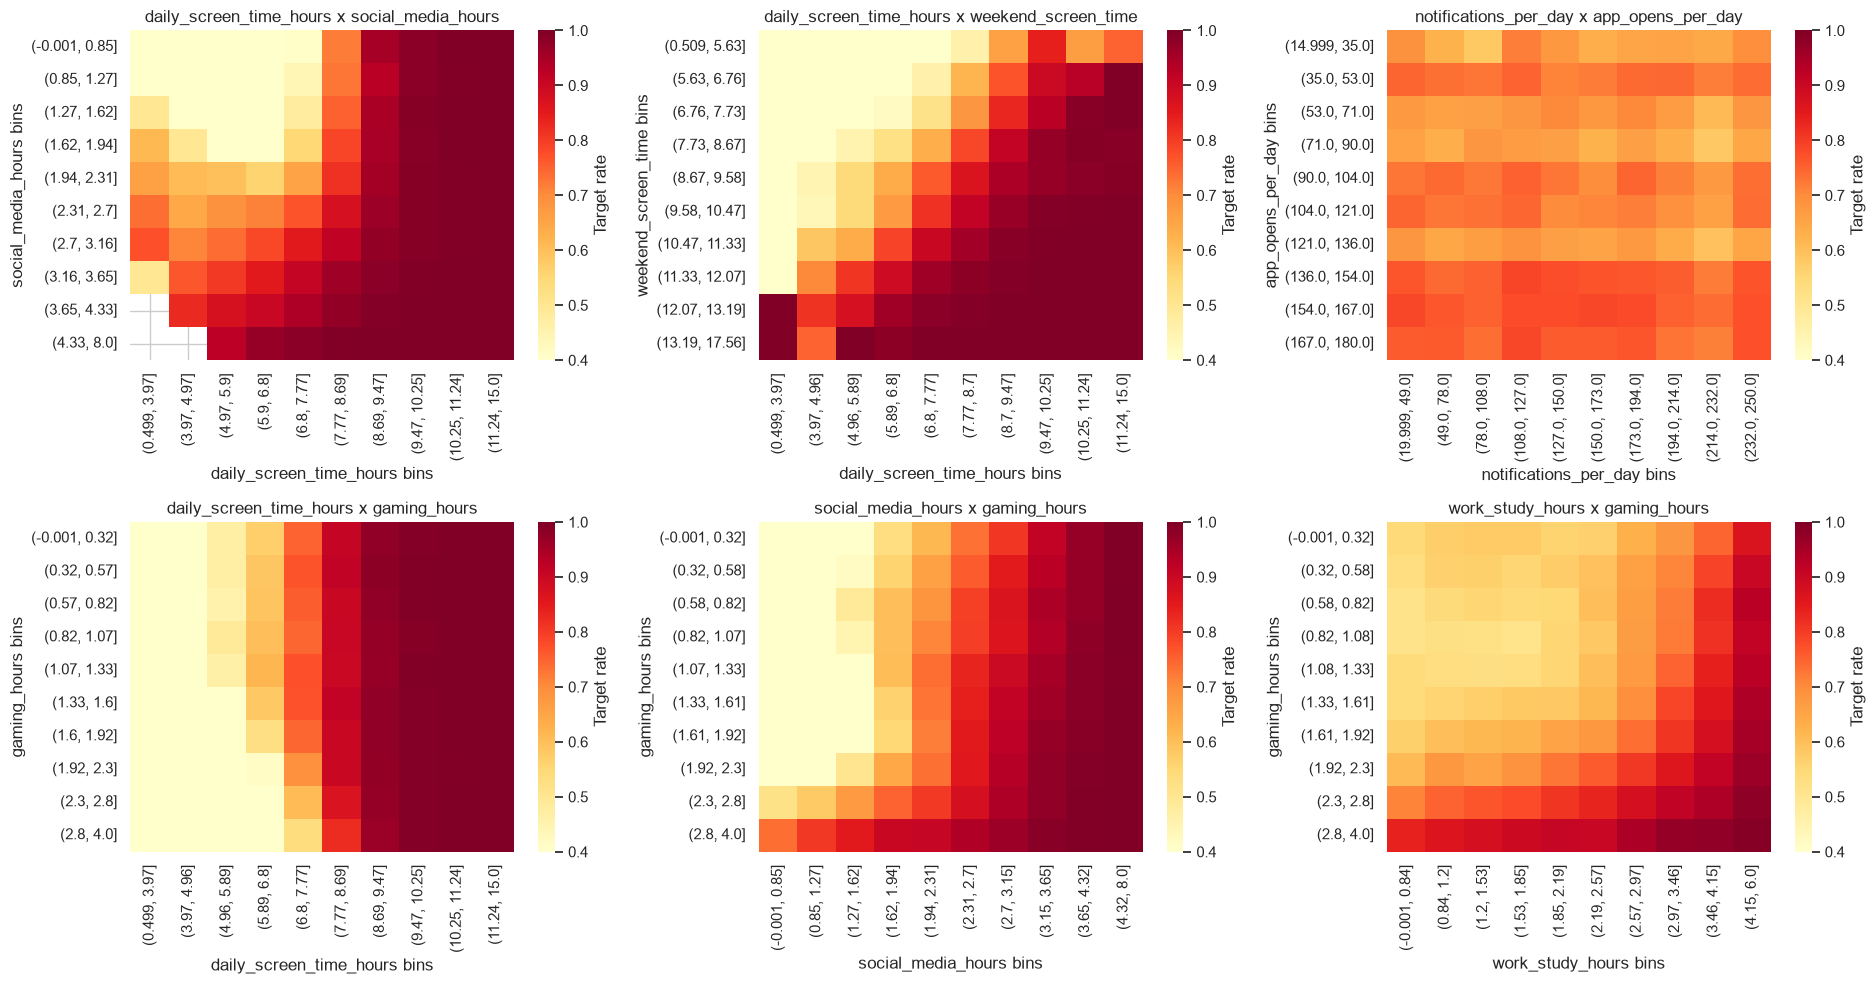

In [15]:
major_features = ['daily_screen_time_hours', 'social_media_hours', 'weekend_screen_time', 'work_study_hours','gaming_hours']
fig, axes = plt.subplots(3, 2, figsize=(14, 9))
for ax, col in zip(axes.flat, major_features):
    frame = train[[col, TARGET]].dropna().copy()
    frame['bin'] = pd.qcut(frame[col], q=20, duplicates='drop')
    curve = frame.groupby('bin', observed=False).agg(x=(col, 'median'), target_rate=(TARGET, 'mean'))
    ax.plot(curve['x'], curve['target_rate'], marker='o')
    ax.set(title=f'Target rate vs {col}', xlabel=col, ylabel='Addicted-label rate')
    ax.yaxis.set_major_formatter(lambda value, pos: f'{value:.0%}')
plt.tight_layout()
plt.savefig(EDA_DIR / 'target_rate_curves.png', dpi=160)
plt.show()

pairs = [('daily_screen_time_hours', 'social_media_hours'), ('daily_screen_time_hours', 'weekend_screen_time'), ('notifications_per_day', 'app_opens_per_day'), ('daily_screen_time_hours', 'gaming_hours'), ('social_media_hours', 'gaming_hours'), ('work_study_hours', 'gaming_hours')]
fig, axes = plt.subplots(2, 3, figsize=(19, 10))
for ax, (x_col, y_col) in zip(axes.flat, pairs):
    frame = train[[x_col, y_col, TARGET]].dropna().copy()
    frame['x_bin'] = pd.qcut(frame[x_col], q=10, duplicates='drop')
    frame['y_bin'] = pd.qcut(frame[y_col], q=10, duplicates='drop')
    surface = frame.pivot_table(index='y_bin', columns='x_bin', values=TARGET, aggfunc='mean', observed=False)
    sns.heatmap(surface, cmap='YlOrRd', vmin=.4, vmax=1.0, ax=ax, cbar_kws={'label': 'Target rate'})
    ax.set(title=f'{x_col} x {y_col}', xlabel=x_col + ' bins', ylabel=y_col + ' bins')
plt.tight_layout()
plt.savefig(EDA_DIR / 'target_rate_surfaces.png', dpi=160)
plt.show()